## SMBHB model 
This notebook provides the photometric model of Super Massive Black Hole Binaries for two components: Doppler boosting and Stochastic Quasar Variability

In [19]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.time import Time
from astropy import units as u
from astropy import constants as c
from ipywidgets import *

# PlatoSim libraries
import platosim.utilities as ut
import platosim.plot      as pt
from platosim.lightcurve   import LightCurve
from platosim.slurm        import workerOverview
from platosim.matplotlibrc import setup_notebook
setup_notebook()

In [21]:
# Paths to where data is stored
path = '/lhome/nicholas/software/workdir/smbhb'

---
## Quasar LOPS2-Gaia DR3 catalogue
---

In [22]:
df = pd.read_feather(f'{path}/input/starcat_GaiaDR3_LOPS2.ftr')

In [23]:
# Check how many of the AGNs that has a confirmed host galaxy
dh = df[(df.host_galaxy == True) & (df.class_name == 'AGN')]
dh.shape[0]

768

In [24]:
# Start make some general cuts
dt = df[(df.class_name == 'AGN') & (df. p_comb_quasar > 0.999) & (df.Pmag < 19)]
dt.shape[0]

5957

In [25]:
# All quasar above z > 3
ds = dt[dt.z > 3]
ds.shape[0]

130

<IPython.core.display.Javascript object>


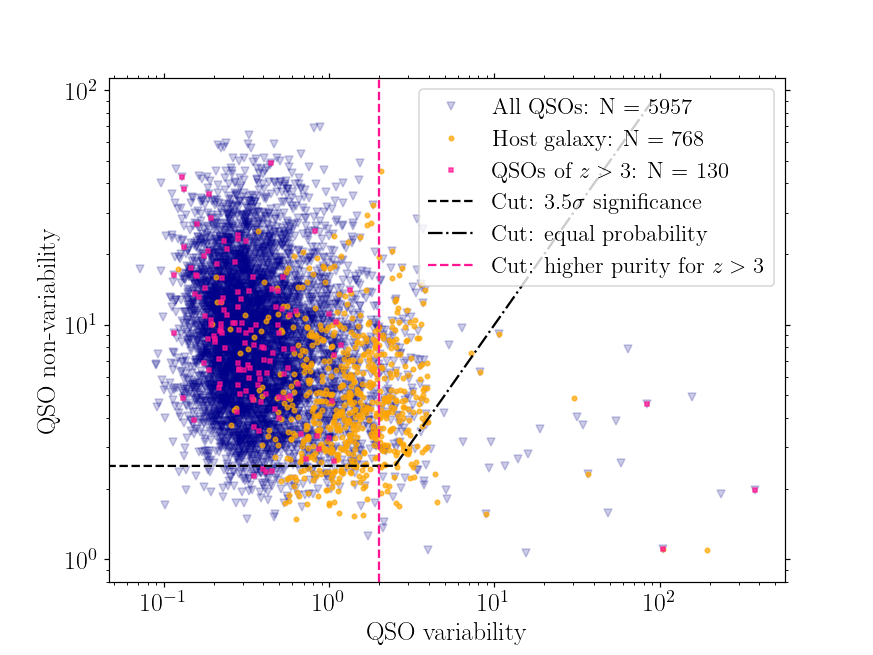

In [26]:
# Plot diagnostic diagram of Butler and Bloom (2011)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
# ax.plot(10**df.qso_var, 10**df.qso_non, '.', c='k', ms=0.5)
ax.plot(10**dt.qso_var, 10**dt.qso_non, 'v', c='darkblue', alpha=0.2, ms=5, label=f'All QSOs: N = {dt.shape[0]}')
ax.plot(10**dh.qso_var, 10**dh.qso_non, '.', c='orange',   alpha=0.7,       label=f'Host galaxy: N = {dh.shape[0]}')
ax.plot(10**ds.qso_var, 10**ds.qso_non, 's', c='deeppink', alpha=0.7, ms=3, label=r'QSOs of $z>3$: ' + f'N = {ds.shape[0]}')

# ax.axhline(y=2.5, xmin=0, xmax=0.1, ls='--', c='limegreen')
def y(x): return x 
ax.plot([0, 2.5], [1, 2.5],         '--', c='k', label=r'Cut: 3.5$\sigma$ significance')
ax.plot([2.5, 90], [y(2.5), y(90)], '-.', c='k', label='Cut: equal probability')
ax.axvline(x=2.0,         ls='--', c='deeppink', label=r'Cut: higher purity for $z>3$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()
ax.set_xlabel('QSO variability')
ax.set_ylabel('QSO non-variability');

In [ ]:
# Plot diagnostic diagram of Butler and Bloom (2011)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

ax.plot(10**dt.qso_var, 10**dt.qso_non, 'v', c='darkblue', alpha=0.2, ms=5, label=f'All QSOs: N = {dt.shape[0]}')
# ax.plot(10**dh.qso_var, 10**dh.qso_non, '.', c='orange',   alpha=0.7,       label=f'Host galaxy: N = {dh.shape[0]}')
# ax.plot(10**ds.qso_var, 10**ds.qso_non, 's', c='deeppink', alpha=0.7, ms=3, label=r'QSOs of $z>3$: ' + f'N = {ds.shape[0]}')

# ax.axhline(y=2.5, xmin=0, xmax=0.1, ls='--', c='limegreen')
def y(x): return x 
ax.plot([0, 2.5], [1, 2.5],         '--', c='k', label=r'Cut: 3.5$\sigma$ significance')
ax.plot([2.5, 90], [y(2.5), y(90)], '-.', c='k', label='Cut: equal probability')
ax.axvline(x=2.0,         ls='--', c='deeppink', label=r'Cut: higher purity for $z>3$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()
ax.set_xlabel('QSO variability')
ax.set_ylabel('QSO non-variability');

In [ ]:
# dx = dt[(dt.z >= 0.5) & (dt.z <= 0.5) & (dt.qso_non > 2.5) |

In [214]:
# Further cut using methodology of Butler and Bloom (2011)
dx = dt[(dt.z >= 0.5) & (dt.z <= 0.5) & (dt.qso_non > 2.5) |
        (dt.z < 0.5) & (dt.qso_var > 0.5) | 
        (dt.z > 3.0) & (dt.qso_var < 2.0)]
dx

,starID,designation,gaiaDR3,ra,dec,Pmag,BP_RP,Ag,plx,plx_err,...,p_spec_quasar,z,z_upper,z_lower,class_name,qso_var,qso_non,agn_score,host_galaxy,ncams
451,25152,4867236336317793536,4867236336317793536,71.656052,-34.729581,15.601887,0.518549,1.5119,-0.090125,0.026048,...,0.978468,0.179096,0.179411,0.178782,AGN,0.708651,0.296442,0.051138,False,6
535,17621,4867295160189943936,4867295160189943936,68.974996,-36.611638,15.986900,0.654427,NaN,-0.107550,0.033483,...,0.916147,0.140009,0.140352,0.139665,AGN,1.144306,0.425970,0.051336,False,6
586,16232,4674576026248524032,4674576026248524032,53.508046,-61.538117,16.157454,0.521955,1.4944,-0.022859,0.037126,...,0.984635,0.175259,0.175495,0.175023,AGN,0.710897,0.255541,0.087276,False,6
608,317651,4829641491143300480,4829641491143300480,57.759443,-50.475138,16.203642,0.484871,NaN,-0.006430,0.036247,...,0.997611,0.267513,0.268021,0.267006,AGN,1.065305,0.396612,0.055192,False,6
769,8850,4838781422067450368,4838781422067450368,62.935489,-43.375964,16.606564,0.704598,NaN,-0.088267,0.039973,...,0.936743,0.142264,0.142583,0.141945,AGN,0.558058,0.542810,0.322660,False,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
351300,4536,4767784818094202624,4767784818094202624,89.402022,-54.749795,18.907022,0.982012,0.0154,0.100134,0.143877,...,0.002708,3.280454,3.287531,3.273388,AGN,-0.394270,0.898335,0.901046,False,24
351309,11361,2883450758303445504,2883450758303445504,88.479457,-39.834121,18.910275,0.727285,0.0046,-0.143040,0.162706,...,0.007978,3.165448,3.210213,3.121160,AGN,-0.149527,0.623955,0.821417,False,24
351323,14064,5574134626926271616,5574134626926271616,96.072524,-38.605643,18.914778,0.936087,NaN,-0.147727,0.164981,...,0.986884,5.683580,5.691095,5.676074,AGN,-0.062507,0.470277,0.716215,True,24
351372,5051,4793829126115785344,4793829126115785344,84.519038,-49.951996,18.929834,0.696159,NaN,-0.199339,0.167107,...,0.999210,0.448650,0.456764,0.440581,AGN,0.528995,1.231549,0.299256,False,24


<IPython.core.display.Javascript object>


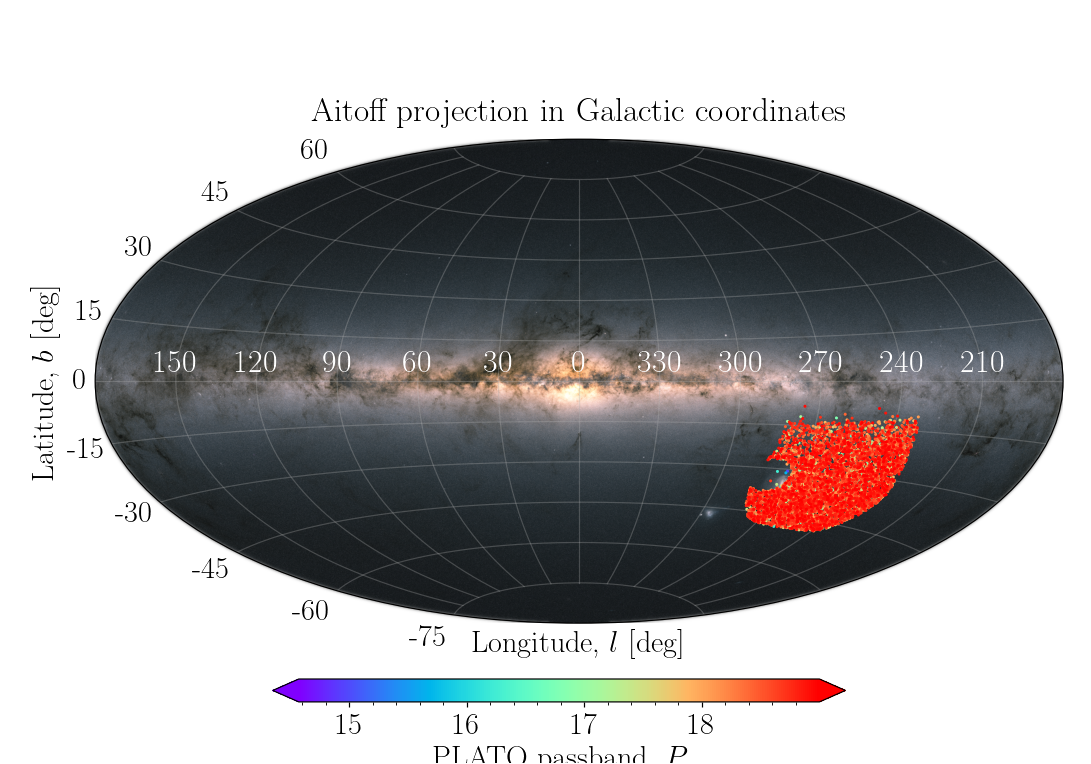

In [30]:
fig, ax = pt.drawStarsInSkyAitoff(dt.ra, dt.dec, magStars=dt.Pmag, figsize=(10,7))

<IPython.core.display.Javascript object>


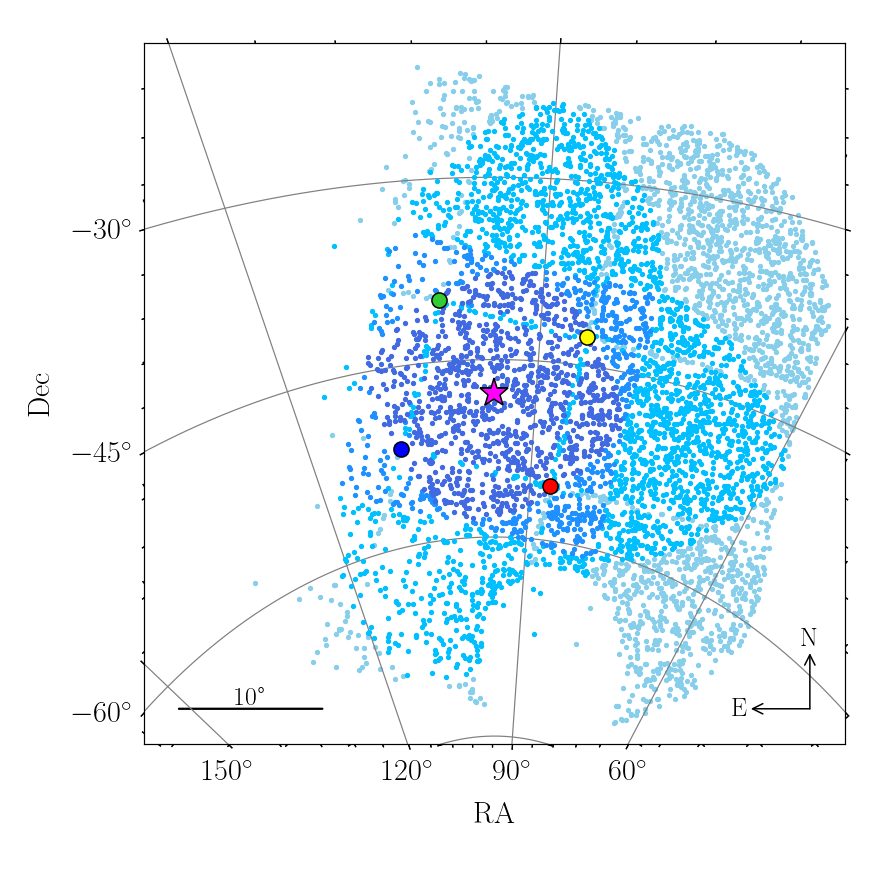

In [31]:
# PLOT THE PLATO SKY FOV WITH DENSITY MAP 
fig, ax = pt.plotPlatoFOV('LOPS2', raStars=None, decStars=None,
                          system="icrs", showGroups=True, showLegend=False, ncamStars=dt, 
                          fovSize=30, fs=20, ms=5, figsize=(8,8))
plt.show()
# fig.savefig(f'{fdir}/LOPS2.png', bbox_inches='tight', dpi=200)

---
## Physical model
---

### Doppler Boosting

In [32]:
def calculate_eccentric_anomaly(M_A, e):
    """
    We use Kepler's equation (M = E – e sin E) to determine the Eccentric anomaly E.
    Newton Raphson method is used to obtain the eccentric anomaly
   
    Parameters
    ----------
    M = mean anomaly
    e = eccentricity
    """
    
    # Initialize E with M
    E = M_A
    tol = 1e-12 * u.rad
    max_iterations = 1000  

    for _ in range(max_iterations):
        E_next = E - (E - e * np.sin(E) * u.rad - M_A) / (1 - e * np.cos(E))
        if np.allclose(E_next, E, atol=tol):
            return E_next
        E = E_next

    raise Exception("Eccentric anomaly solver did not converge.")    

    
def doppler_boosting(time, P, M1, M2, e, i, w, t0):
    """ 
    generates relative flux caused by the doppler boosting effect

    Parameters
    ---------------
    time: time array for the light curve
    P: Orbital period
    M1: Mass of primary Black hole
    M2: Mass of secondary Black hole
    e: eccentricity
    i: inclination angle
    w: argument of periapse
    t0: arbitrary reference time
    alpha: spectral index
    
    -->Starts by Calculating mean anomaly
    -->Then calls the eccentric anomaly used to calculate true anomaly 'f' 
    -->Radial velocity RV2 of secondary Black Hole is used to calculate flux    
    """
    
    mean_anomaly = 2 * np.pi * (time - t0) / P * u.rad
    E = calculate_eccentric_anomaly(mean_anomaly, e)
    
    M = G * (M1 + M2)  
    
    phi = 2 * np.pi * (time - t0) / P * u.rad
    a = M**(1/3)*((P/(2*np.pi))**(2/3))
    
    f =  2*np.arctan(np.sqrt((1 + e) / (1 - e)) * np.tan(E/2))  
    K2 = (2 * np.pi / P) * (M1/(M1+M2)) * a * np.sin(i) / np.sqrt(1 - e**2)
    RV2 = K2 * (np.cos(w + f) + e * np.cos(w))    
    MN = (0.89)*(3 - alpha) * (-RV2 / c_phot) + 1
    
    return MN

### Stochastic Quasar Variability
The stochastic quasar variability is best described by the damped random walk model. We use the power spectral density(PSD) for Damped Random Walk to generate the model light curve

In [33]:
def getRedNoise(time, currenttime, kicktimestep, Ntime, timescale, varscale, noise, mu, sigma):

    signal = np.zeros(Ntime)
    
    for i in range(Ntime):
    
        # Compute the contribution of each component separately.
        # First advance the time series right *before* the time point i,
        while( (currenttime + kicktimestep) < time[i]):
            noise = noise * (1.0 - kicktimestep/timescale) + np.random.normal(mu[0], sigma[0])
            currenttime = currenttime + kicktimestep

        # Then advance the time series with a small time step right *on* time[i]
        delta  = time[i] - currenttime
        #sigma1 = np.sqrt(delta/timescale)*varscale
        sigma1 = varscale * 0.66  # Correction factor to have varscale in RMS arcsec
        noise  = noise * (1.0 - delta/timescale) + np.random.normal(mu[0], sigma1)
        currenttime = time[i]

        # Add the different components to the signal. 
        signal[i] = np.sum(noise)*1e-6 

    return signal


#is tau and sigma dependent on orbital properties of binary or from the the properties of the black hole itself


def modelRedNoise(time, timescale, varscale):

    """Function to generate a red noise time series.
    
    Parameters
    ----------
    time : ndarray
        Time points: time[0..Ntime-1]
    timescale : ndarray
        Time scale tau of each red noise component: timescale[0..Ncomp-1]
    varscale : ndarray
        Variation scale of each red noise component: varscale[0..Ncomp-1]
            
    Returns
    -------
    signal : ndarray
        Signal containing all red noise components: signal[0..Ntime-1]
    """

    Ntime = len(time)
    Ncomp = len(timescale)

    # Set the kick (= excitation) timestep to be one 100th of the
    # shortest noise time scale (i.e. kick often enough).
    kicktimestep = min(timescale) / 100.0
    currenttime  = time[0] - kicktimestep
    
    # Predefine some arrays
    delta = 0.0
    noise = np.zeros(Ncomp)
    mu    = np.zeros(Ncomp)
    sigma = np.sqrt(kicktimestep/timescale)*varscale
    
    # Warm up the first-order autoregressive process
    for i in range(2000):
        noise = noise * (1.0 - kicktimestep / timescale) + np.random.normal(mu, sigma)

    # Start simulating the granulation time series
    return getRedNoise(time, currenttime, kicktimestep, Ntime,
                       timescale, varscale, noise, mu, sigma)
    


def modelRedNoisePSD(freq, timescale, varscale):

    """Function to generate a red noise model from the PSD.

    Compute the mean power spectral density (PSD) corresponding to the 
    red noise time series that is generated by modelRedNoise().

    INPUT: freq:       frequency points of the PSD  [microHz | mHz | Hz]
           timescale:  see the function rednoise()
           varscale:   see the function rednoise()

    OUTPUT: psd:  power spectral density   [ppm^2/microHz | ppm^2/microHz | ppm^2/microHz]
    """

    psd = np.zeros_like(1 / (freq**2))  

    for n in range(len(timescale)):
        sigma = varscale[n] 
        tau = timescale[n]
        num =  sigma * sigma * tau * tau * 2
        denom = (1.0  + (2.0*np.pi*freq*tau)**2)
        psd += num / denom
    
    return psd

### Example: Model Spikey 
Finally we define our constants and parameters of the SPIKEY SMBHB. We also define the time series here and convert necessary units from (seconds) to Modified Julian Date for a better comparison with the light curve produced by Hu et.al  

In [34]:
# Constants (in SI units)
G = c.G
h = c.h                                                       
c_phot = c.c                                                                   
                                                              
# Parameters relating to Spikey (SI)
alpha = 2.09                                               
P = 1.144 * 365.25 * 86400 * u.s                                        
M2 = 10**36.7 * u.kg                                                           
M1 = 10**37.4 * u.kg                                                           
i =  1.4296097932 * u.rad
e = 0.524
w = 1.477 * u.rad
t0 = 1.693 * 365.25 * 86400 * u.s

# Construct time array
time = np.arange(0, 36101894.4, 25)                           
time *= u.s
time_d = time.to(u.d)
reference_mjd = 55365 * u.day
t_mjd = reference_mjd + time_d
freq  = 1 / time_d

In [35]:
# Model Doppler beaming
model_beam = doppler_boosting(time, P, M1, M2, e, i, w, t0)

In [36]:
# Model QSO variability
# tau   = np.array([31]) * u.day
# sigma = np.array([9])   # ppm
tau   = np.array([10]) * u.day
sigma = np.array([15]) # ppm
model_red = modelRedNoise(time_d, tau, sigma)

In [37]:
# Combined model (Beaming + QSO varibility)
model = model_beam + model_red

<IPython.core.display.Javascript object>


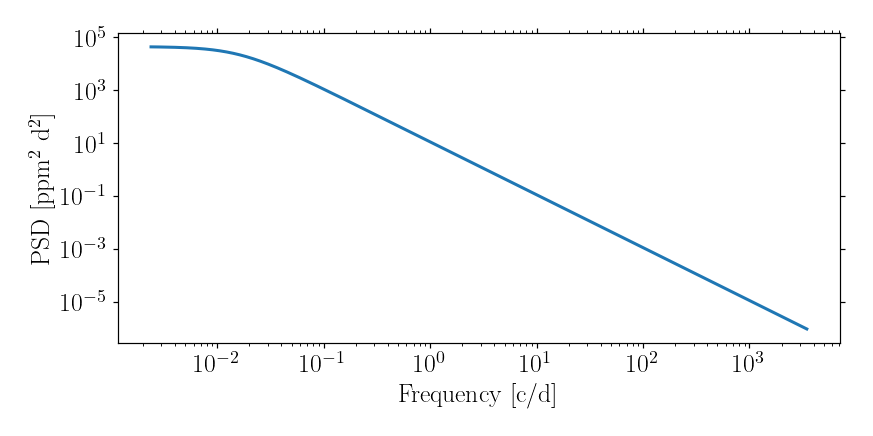

In [43]:
# Plotting the PSD as a function of frequency
tau   = np.array([10]) * u.day
sigma = np.array([15]) # ppm
PSD = modelRedNoisePSD(freq, tau, sigma)

fig = plt.figure(figsize = (8, 4))
for i in range(len(tau)):
    plt.loglog(freq, PSD, lw=2)
plt.xlabel(r"Frequency [c/d]")
plt.ylabel(r"PSD [ppm$^2$ d$^2$]")
plt.tight_layout()
plt.show()

<IPython.core.display.Javascript object>


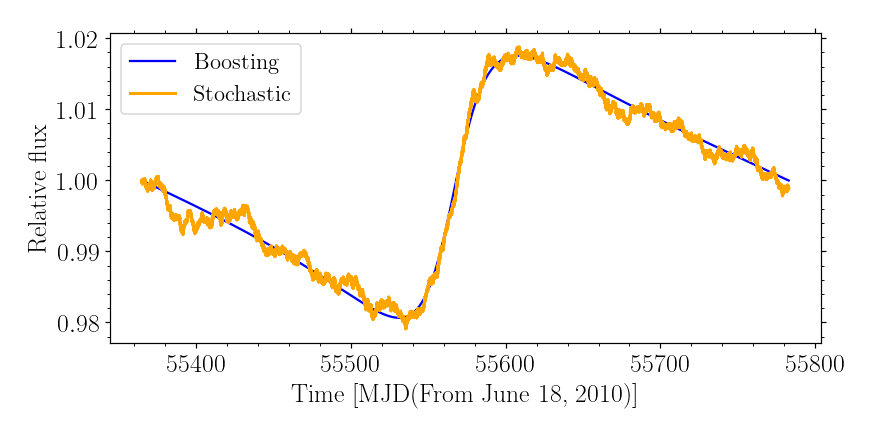

In [42]:
# Plotting the combined (Doppler + Stochastic Quasar Variability) model
fig = plt.figure(figsize = (8, 4))
plt.plot(t_mjd, model_beam, color='blue', label="Boosting")
for i in range(len(tau)):
    plt.plot(t_mjd, model, lw=2, color = 'orange', label="Stochastic")
plt.xlabel(r"Time [MJD(From June 18, 2010)]")
plt.ylabel(r"Relative flux")
plt.legend()
plt.tight_layout()
plt.show()